In [2]:
import sys
sys.path.append('../code')

import glob
import os
import jax
from jax import config
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
# jax.config.update("jax_platform_name", "gpu")

import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np
import jax.numpy as jnp
from jax import jit, vmap
import joblib

import jaxley as jx
import jaxley.optimize.transforms as jt
from jaxley.connect import fully_connect, connect, sparse_connect, connectivity_matrix_connect
import optax
import pickle

import torch
from torch import optim
from sbi import utils as utils
from tqdm import tqdm

from network_utils import (make_network, set_train_parameters, get_currents_nocontext, log_scale_forward, linear_scale_forward,
                           get_prior_dict, initialize_params, get_parameter_names)
from flow_utils import UniformPrior, PriorFiltered
from sklearn.linear_model import LinearRegression, Ridge

from neurodsp.spectral import compute_spectrum

import prior_configurations as prior_config
save_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations'

data_path =  '/users/ntolley/data/ntolley/dendractor/memory_permutations/random_initialization'
file_list = os.listdir(data_path)
memory_sim_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)

    # Calculate spikes
    threshold = 0.0
    output_array = res_dict['output_array']
    gid_ranges = res_dict['gid_ranges']
    input_list = res_dict['input_list']
    num_cond = input_list.shape[0]
    cell_type_list = ['E', 'I', 'cue']
    st_data = list()
    st_data_labels = list()
    for cell_type in cell_type_list:
        for gid in gid_ranges[cell_type]:
            spike_times_list = list()
            spike_count = 0
            for sim_idx in range(output_array.shape[0]):
                s = output_array[sim_idx, gid, :]
                above_threshold = s > threshold
                spike_times = (np.where(np.diff(above_threshold.astype(int)) == 1)[0] + 1).astype(float)
                spike_times_list.append(spike_times)
            st_data.append(spike_times_list)
            st_data_labels.append(cell_type)

    res_dict['st_data'] = st_data
    res_dict['st_data_labels'] = st_data_labels
    
    memory_sim_dict[res_dict['name']] = res_dict


data_path =  '/users/ntolley/data/ntolley/dendractor/memory_permutations/cell_ephys_sim'
threshold = 0.0
file_list = os.listdir(data_path)
cell_ephys_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    cell_ephys_dict[res_dict['name']] = res_dict




100%|██████████| 4/4 [00:00<00:00,  8.60it/s]


In [3]:
t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(0 / downsample_factor)

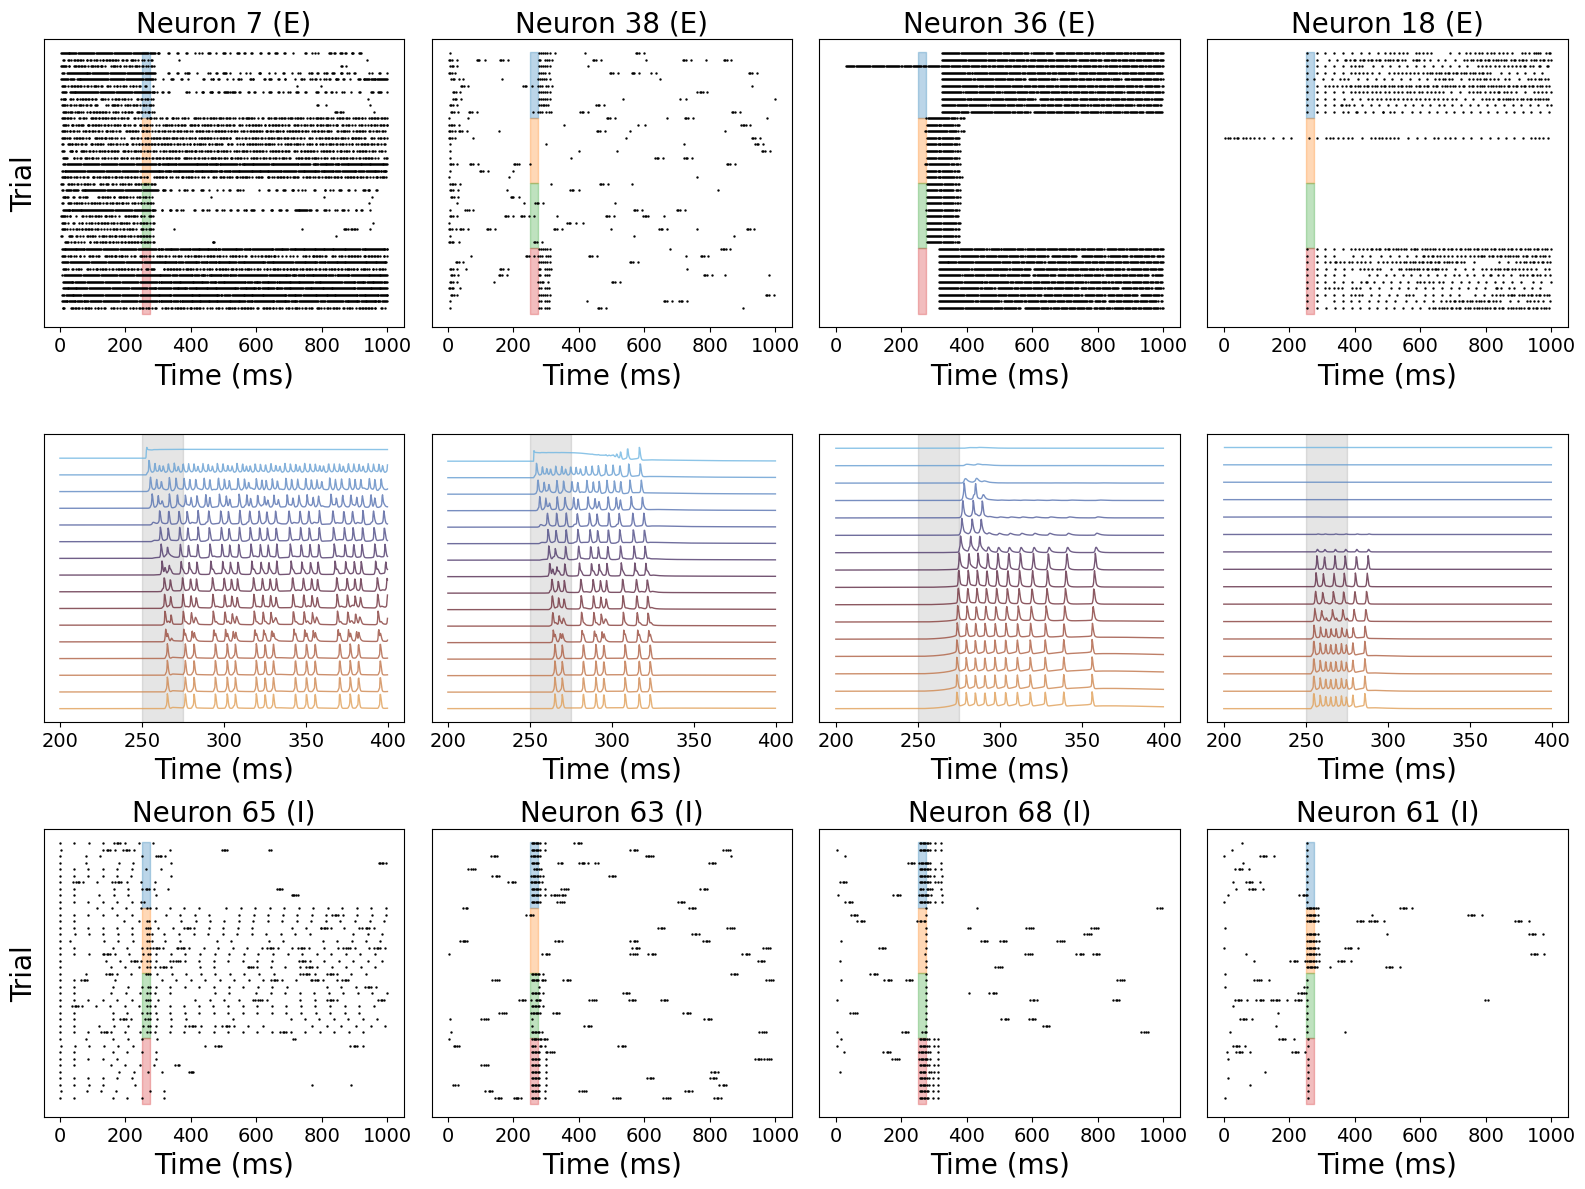

In [10]:
config_list = [
    'cuedendnmda_Esomaampa_Edendampa',
    'cuedendampa_Esomaampa_Edendampa',
    'cuesomanmda_Esomaampa_Edendampa',
    'cuesomaampa_Esomaampa_Edendampa',
    ]


E_cell_indices = [7, 38, 36, 18]
I_cell_indices = [65, 63, 68, 61]

ephys_cell_indices = [4, 8, 28, 8]

cell_groups = [E_cell_indices, I_cell_indices]

cmap = mpl.colormaps['managua']

ticksize = 14
labelsize = 20
voltage_spacing = 130
num_comps = 16

sample_start = 800
sample_stop = 1600

num_repeats = 10
cond_order = [0,1,2,3]
trial_indices = list()
for cond_idx in range(num_cond):
    for repeat_idx in range(num_repeats):
        trial_indices.append((repeat_idx * num_cond) + cond_idx)


plt.figure(figsize=(16, 12))
for config_idx, name in enumerate(config_list):
    output_array = cell_ephys_dict[name]['output_array']

    #___Plot membrane potential traces___
    cell_idx = ephys_cell_indices[config_idx]
    plt.subplot(3, 4, (config_idx + 4) + 1)

    comp_start_idx = cell_idx * num_comps
    comp_end_idx = comp_start_idx + num_comps
    voltages = output_array[1, comp_start_idx:comp_end_idx, :-1]
    plot_voltages = voltages[:, sample_start:sample_stop].T + np.arange(num_comps) * voltage_spacing
    for comp_idx, color in enumerate(cmap(np.linspace(0.1, 0.9, num_comps))):
        _   = plt.plot(time_vec[sample_start:sample_stop], plot_voltages[:, comp_idx], color=color, linewidth=1, alpha=0.8)

    # if config_idx == 0:
        # plt.ylabel('Membrane potential', fontsize=labelsize)
    plt.xlabel('Time (ms)', fontsize=labelsize)
    plt.xticks(fontsize=ticksize)
    _ = plt.yticks([])

    voltage_ylim = plt.ylim()
    plt.ylim(voltage_ylim[0], voltage_ylim[1])
    plt.fill_between(x=[250, 275], y1=voltage_ylim[0], y2=voltage_ylim[1], zorder=-0.9, alpha=0.1, color='k')


    for group_idx, cell_indices in enumerate(cell_groups):
        cell_idx = cell_indices[config_idx]

        #___ Plot single neuron spike trains___
        st_data = memory_sim_dict[name]['st_data']
        st_data_labels = memory_sim_dict[name]['st_data_labels']

        if group_idx == 0:
            subplot_offset = 0
        else:
            subplot_offset = 8

        plt.subplot(3, 4, config_idx+subplot_offset+1)
        if config_idx == 0:
            plt.ylabel('Trial', fontsize=labelsize)

        for row_idx, trial_idx in enumerate(trial_indices):  
            st_trial = st_data[cell_idx][trial_idx] * dt
            y_pos = np.repeat(row_idx, len(st_trial))
            plt.scatter(st_trial, y_pos, color='k', s=0.5)

        cond_colors = [0,1,2,3]
        cond_labels = ['(-1,-1)', '(1,1)', '(-1,1)', '(1,-1)']
        for cond_idx in range(num_cond):
            y_offset = 0
            label = None
            if cond_idx > 3:
                y_offset = 10
                label = cond_labels[cond_idx]

            y1 = num_repeats * cond_idx - 0.1 + y_offset
            y2 = y1 + num_repeats
            plt.fill_between(x=[250, 275], y1=y1, y2=y2, zorder=-0.9, alpha=0.3, color=f'C{cond_colors[cond_idx]}', label=label)
        plt.xlim(-50, 1050)

        _ = plt.yticks([])
        _ = plt.xticks(fontsize=ticksize)
        plt.xlabel('Time (ms)', fontsize=labelsize)

        plt.title(f'Neuron {cell_idx} ({st_data_labels[cell_idx]})', fontsize=labelsize)
        # plt.legend()
        plt.gca().invert_yaxis()

plt.tight_layout()

figure_path = '/users/ntolley/data/ntolley/dendractor/memory_permutations/figures'
plt.savefig(f'{figure_path}/cell_ephys.png')

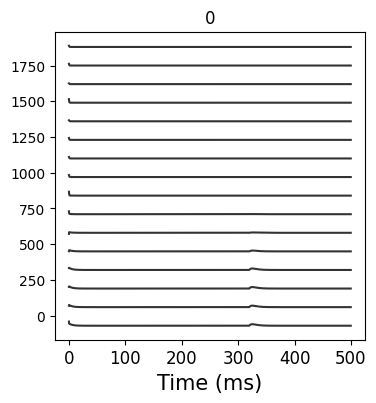

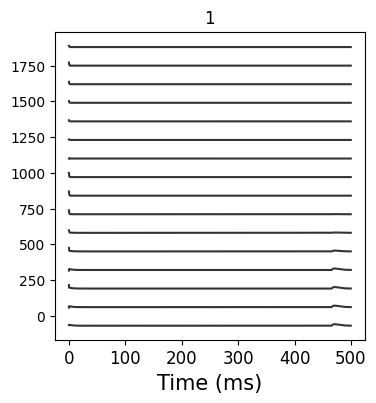

In [ ]:
ticksize = 12
labelsize = 15
voltage_spacing = 130

output_array = cell_ephys_dict[config_list[3]]['output_array']
# neuron_idx = 11
for neuron_idx in range(0, 2):
    num_comps = 16
    comp_start_idx = neuron_idx * num_comps
    comp_end_idx = comp_start_idx + num_comps

    voltages = output_array[1, comp_start_idx:comp_end_idx, :-1]

    sample_start = 0
    sample_stop = 2000

    # sample_start = 1100
    # sample_stop = 1300

    plt.figure(figsize=(4,4))
    _ = plt.plot(time_vec[:(sample_stop-sample_start)], voltages[:, sample_start:sample_stop].T + np.arange(num_comps) * voltage_spacing, color='k', alpha=0.8)

    plt.title(neuron_idx)
    plt.xlabel('Time (ms)', fontsize=labelsize)
    plt.xticks(fontsize=ticksize)
